# 🛒 AI-Powered E-Commerce Product Recommendation Engine

**Skills demonstrated:**
- 🐍 Python · Pandas · NumPy · SQL-style querying
- 🤖 Machine Learning: Scikit-learn, PyTorch (embeddings), Matrix Factorization
- 🧠 GenAI: LLM-powered recommendation explanations (Azure OpenAI / OpenAI compatible)
- 📊 Visualization: Matplotlib, Seaborn
- ☁️ Azure-ready: structured for Azure ML deployment

---

## 📌 Project Overview

We build a **hybrid recommendation engine** that:
1. Cleans and explores real e-commerce transaction data (Online Retail II dataset)
2. Engineers user and product features
3. Trains **Collaborative Filtering** (Matrix Factorization via SVD)
4. Trains a **Content-Based Filter** using TF-IDF on product descriptions
5. **Combines** both into a hybrid recommender
6. Uses a **GenAI layer** (LLM) to generate natural language recommendation explanations
7. Evaluates the system with Precision@K and Recall@K
8. Produces rich **visualizations** of user behavior and recommendations


## 1. 📦 Install & Import Dependencies

In [1]:
# Install any missing packages (Kaggle/Colab)
# !pip install scikit-surprise openai azure-ai-inference --quiet

import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from datetime import datetime

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import scipy.sparse as sp

# PyTorch (Neural Collaborative Filtering)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Utilities
from collections import defaultdict
import json, re

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ All dependencies loaded!')
print(f'   PyTorch version: {torch.__version__}')
print(f'   Pandas version:  {pd.__version__}')

✅ All dependencies loaded!
   PyTorch version: 2.10.0+cpu
   Pandas version:  2.3.3


## 2. 📥 Load & Explore the Data

We use the **Online Retail II UCI dataset** — real UK-based online retail transactions (2009–2011).  
Download from: https://archive.ics.uci.edu/ml/datasets/Online+Retail+II  
Or on Kaggle: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

> **If running on Kaggle**, the path below will work directly after adding the dataset.

In [2]:
# ─── DATA LOADING ─────────────────────────────────────────────────────────────
# Try Kaggle path first, then local
import os

KAGGLE_PATH = '/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv'
LOCAL_PATH  = 'online_retail_II.csv'

if os.path.exists(KAGGLE_PATH):
    df_raw = pd.read_csv(KAGGLE_PATH, encoding='unicode_escape')
    print('📂 Loaded from Kaggle')
elif os.path.exists(LOCAL_PATH):
    df_raw = pd.read_csv(LOCAL_PATH, encoding='unicode_escape')
    print('📂 Loaded from local')
else:
    # ── Synthetic fallback so the notebook runs end-to-end anywhere ────────
    print('⚠️  Dataset not found — generating synthetic data for demo...')
    np.random.seed(42)
    N = 20_000

    products = [
        ('85123A', 'WHITE HANGING HEART T-LIGHT HOLDER'),
        ('71053',  'WHITE METAL LANTERN'),
        ('84406B', 'CREAM CUPID HEARTS COAT HANGER'),
        ('84029G', 'KNITTED UNION FLAG HOT WATER BOTTLE'),
        ('84029E', 'RED WOOLLY HOTTIE WHITE HEART'),
        ('22752',  'SET 7 BABUSHKA NESTING BOXES'),
        ('21730',  'GLASS STAR FROSTED T-LIGHT HOLDER'),
        ('22633',  'HAND WARMER UNION JACK'),
        ('22632',  'HAND WARMER RED POLKA DOT'),
        ('20727',  'LUNCH BAG BLACK SKULL'),
        ('22629',  'SPACEBOY LUNCH BOX'),
        ('22745',  'POPPY PLAY ROOM LAMP'),
        ('21212',  'PACK OF 72 RETROSPOT CAKE CASES'),
        ('22423',  'REGENCY CAKESTAND 3 TIER'),
        ('47566',  'PARTY BUNTING'),
        ('85099B', 'JUMBO BAG RED RETROSPOT'),
        ('22111',  'SCOTTIE DOG HOT WATER BOTTLE'),
        ('22110',  'BIRD FEEDER RED CLASSIC'),
        ('84991',  '60 TEATIME FAIRY CAKE CASES'),
        ('21977',  'PACK OF 60 PINK PAISLEY CAKE CASES'),
    ]

    stock_codes = [p[0] for p in products]
    descriptions = [p[1] for p in products]

    customer_ids  = np.random.choice(range(12000, 12500), N)
    stock_choices = np.random.choice(len(products), N, p=np.random.dirichlet(np.ones(len(products))))

    df_raw = pd.DataFrame({
        'Invoice':     [f'5{np.random.randint(10000,99999)}' for _ in range(N)],
        'StockCode':   [stock_codes[i] for i in stock_choices],
        'Description': [descriptions[i] for i in stock_choices],
        'Quantity':    np.random.choice([1,2,3,4,5,6,12], N, p=[.3,.25,.2,.1,.08,.05,.02]),
        'InvoiceDate': pd.to_datetime('2010-12-01') + pd.to_timedelta(np.random.randint(0, 365, N), unit='D'),
        'Price':       np.round(np.random.uniform(0.5, 15.0, N), 2),
        'Customer ID': customer_ids,
        'Country':     np.random.choice(['United Kingdom','Germany','France','Spain','Belgium'], N, 
                                         p=[.7,.1,.1,.05,.05])
    })
    print(f'✅ Synthetic dataset created: {N:,} rows')

print(f'\nShape: {df_raw.shape}')
df_raw.head()

📂 Loaded from Kaggle

Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,13085.0000,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085.0000,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085.0000,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,13085.0000,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,13085.0000,United Kingdom


In [3]:
# ─── BASIC EDA ─────────────────────────────────────────────────────────────────
print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(df_raw.info())
print('\nMissing values:')
print(df_raw.isnull().sum())
print('\nBasic stats:')
df_raw.describe()

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Basic stats:


,Quantity,Price,Customer ID
count,1067371.0000,1067371.0000,824364.0000
mean,9.9389,4.6494,15324.6385
std,172.7058,123.5531,1697.4645
min,-80995.0000,-53594.3600,12346.0000
25%,1.0000,1.2500,13975.0000
50%,3.0000,2.1000,15255.0000
75%,10.0000,4.1500,16797.0000
max,80995.0000,38970.0000,18287.0000


## 3. 🧹 Data Cleaning & Feature Engineering

In [4]:
# ─── CLEANING ──────────────────────────────────────────────────────────────────
df = df_raw.copy()

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Drop rows missing CustomerID or Description
df = df.dropna(subset=['Customer_ID', 'Description'])
df['Customer_ID'] = df['Customer_ID'].astype(int)

# Remove returns (negative Quantity) and zero prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Remove test/service stock codes
df = df[~df['StockCode'].str.upper().isin(['POST','D','M','BANK CHARGES','PADS','DOT'])]

# Clean description text
df['Description'] = df['Description'].str.strip().str.upper()

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Extract time features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['DayOfWeek']   = df['InvoiceDate'].dt.dayofweek
df['Hour']        = df['InvoiceDate'].dt.hour

print(f'Clean dataset shape: {df.shape}')
print(f'Unique customers:    {df["Customer_ID"].nunique():,}')
print(f'Unique products:     {df["StockCode"].nunique():,}')
print(f'Unique invoices:     {df["Invoice"].nunique():,}')
print(f'Total revenue:       £{df["Revenue"].sum():,.2f}')
df.head()

Clean dataset shape: (802932, 13)
Unique customers:    5,862
Unique products:     4,625
Unique invoices:     36,645
Total revenue:       £17,451,756.30


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Revenue,Year,Month,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,13085,United Kingdom,83.4000,2009,12,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085,United Kingdom,81.0000,2009,12,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085,United Kingdom,81.0000,2009,12,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.1000,13085,United Kingdom,100.8000,2009,12,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.2500,13085,United Kingdom,30.0000,2009,12,1,7


In [5]:
# ─── FEATURE ENGINEERING ───────────────────────────────────────────────────────

# 1. Customer-level features (RFM)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_ID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice',      'nunique'),
    Monetary  = ('Revenue',      'sum'),
    AvgBasket = ('Revenue',      'mean'),
    UniqueProducts = ('StockCode', 'nunique')
).reset_index()

# RFM Scores (1–5)
def score_col(series, ascending=True):
    pct = series.rank(pct=True)
    if not ascending:
        pct = 1 - pct
    return pd.cut(pct, bins=5, labels=[1,2,3,4,5]).astype(int)

rfm['R_Score'] = score_col(rfm['Recency'],   ascending=False)
rfm['F_Score'] = score_col(rfm['Frequency'], ascending=True)
rfm['M_Score'] = score_col(rfm['Monetary'],  ascending=True)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

def segment_customer(row):
    r = int(row['R_Score']); f = int(row['F_Score']); m = int(row['M_Score'])
    if r >= 4 and f >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4: return 'Recent Customers'
    elif f >= 4: return 'Frequent Buyers'
    elif r <= 2 and f <= 2: return 'At Risk'
    else: return 'Potential'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# 2. Product-level features
product_features = df.groupby('StockCode').agg(
    Description   = ('Description',  'first'),
    TotalSold     = ('Quantity',      'sum'),
    AvgPrice      = ('Price',         'mean'),
    NumCustomers  = ('Customer_ID',   'nunique'),
    TotalRevenue  = ('Revenue',       'sum')
).reset_index()

product_features['Popularity'] = MinMaxScaler().fit_transform(
    product_features[['TotalSold']])

print('✅ Feature engineering complete')
print(f'\nCustomer segments:')
print(rfm['Segment'].value_counts())
rfm.head()

✅ Feature engineering complete

Customer segments:
Segment
At Risk             1630
Champions           1402
Loyal Customers     1191
Potential            844
Recent Customers     515
Frequent Buyers      280
Name: count, dtype: int64


,Customer_ID,Recency,Frequency,Monetary,AvgBasket,UniqueProducts,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,12,77556.4600,2281.0724,27,2,5,5,255,Frequent Buyers
1,12347,2,8,5633.3200,22.2661,126,5,4,5,545,Champions
2,12348,75,5,1658.4000,36.0522,24,3,4,4,344,Loyal Customers
3,12349,19,3,3678.6900,21.3877,137,5,3,5,535,Loyal Customers
4,12350,310,1,294.4000,18.4000,16,2,1,2,212,At Risk


## 4. 📊 Exploratory Data Analysis & Visualizations

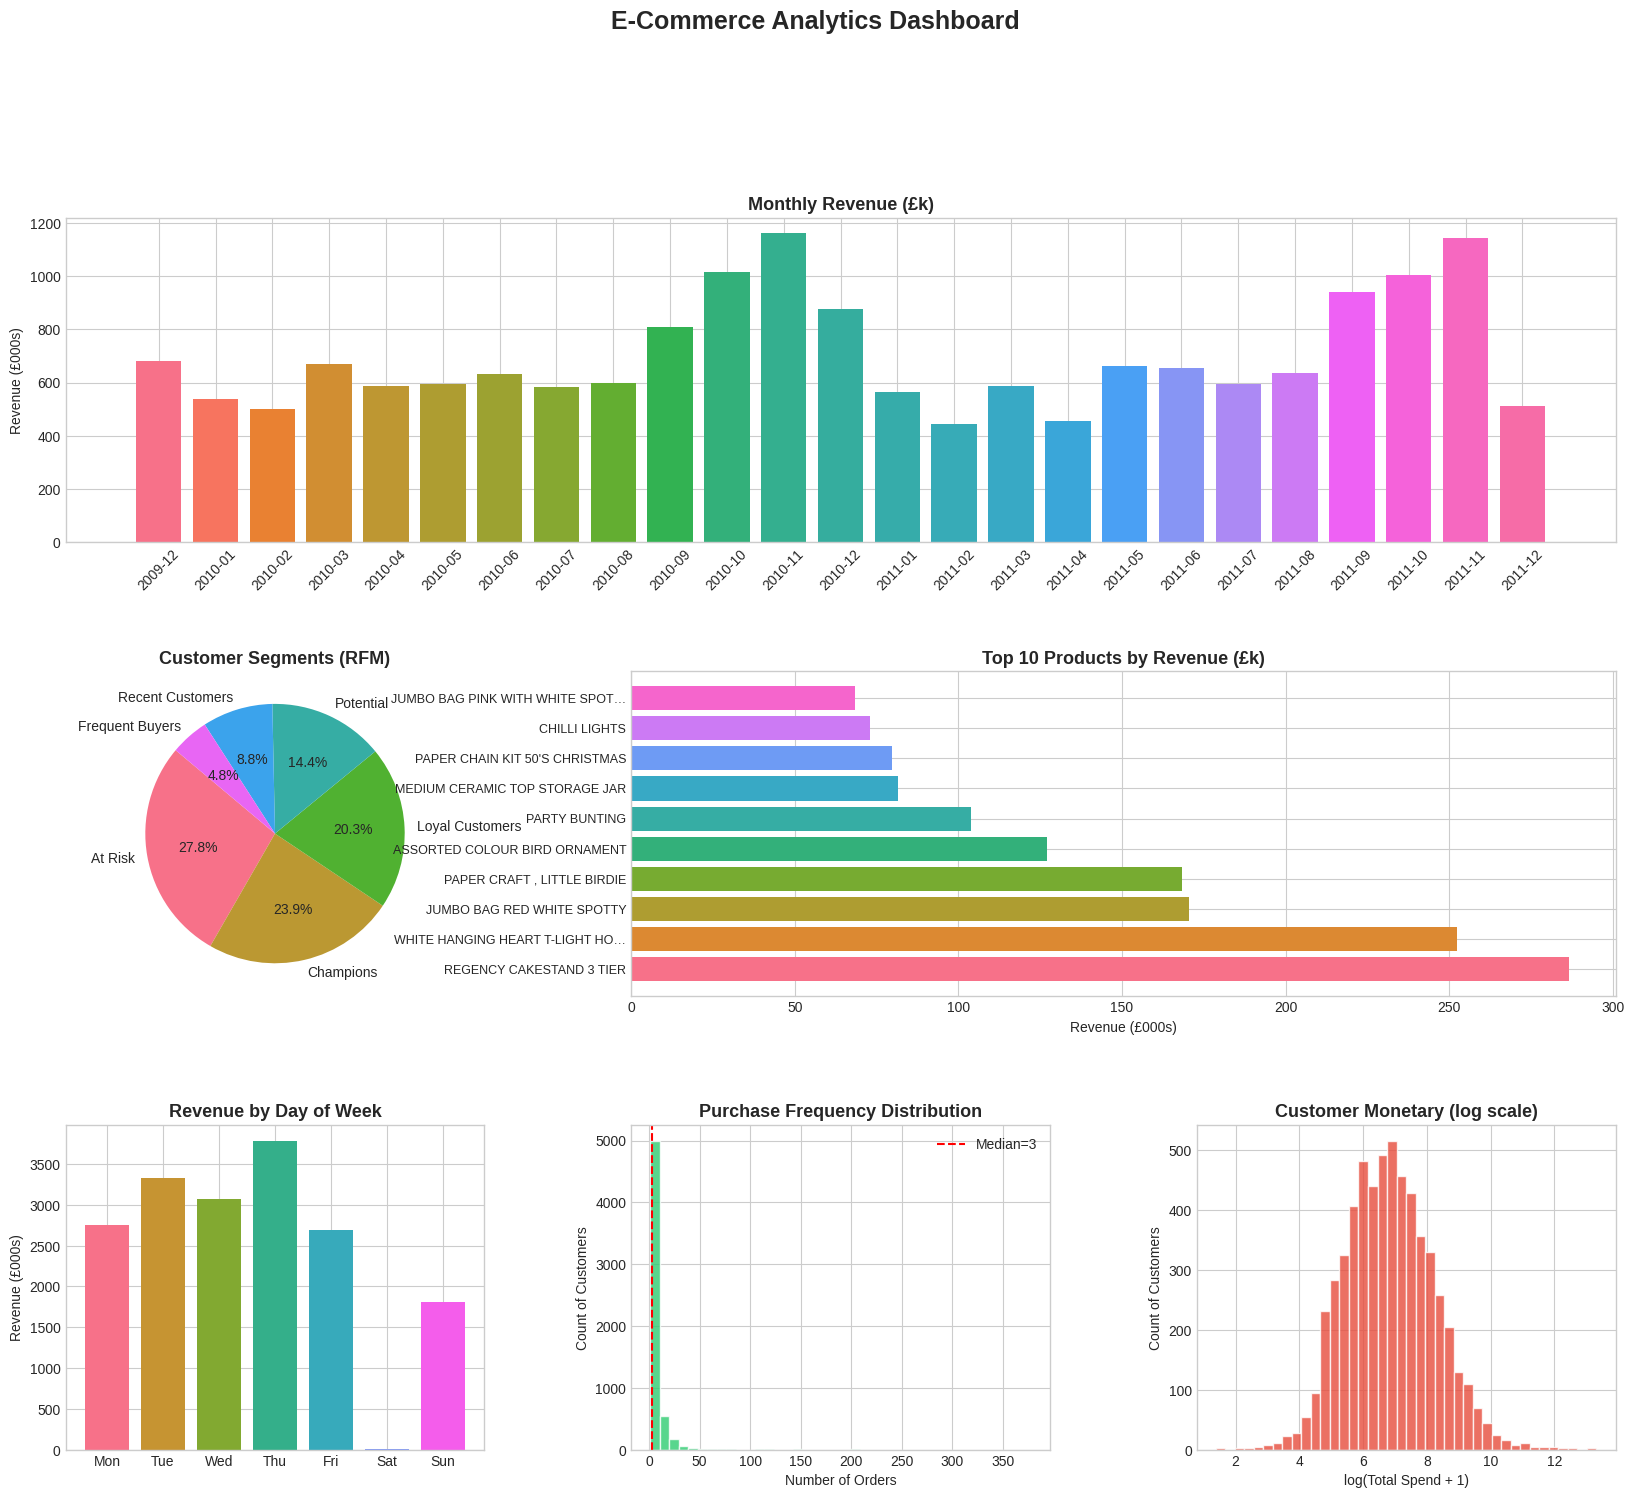

💾 Saved: eda_dashboard.png


In [6]:
# ─── VISUALIZATION DASHBOARD ───────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('E-Commerce Analytics Dashboard', fontsize=18, fontweight='bold', y=1.01)

# 1. Revenue by Month
ax1 = fig.add_subplot(gs[0, :])
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
ax1.bar(monthly['Period'], monthly['Revenue']/1000, color=sns.color_palette('husl', len(monthly)))
ax1.set_title('Monthly Revenue (£k)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Revenue (£000s)')
ax1.tick_params(axis='x', rotation=45)

# 2. Customer Segments
ax2 = fig.add_subplot(gs[1, 0])
seg_counts = rfm['Segment'].value_counts()
wedges, texts, autotexts = ax2.pie(seg_counts.values, labels=seg_counts.index, 
                                    autopct='%1.1f%%', startangle=140,
                                    colors=sns.color_palette('husl', len(seg_counts)))
ax2.set_title('Customer Segments (RFM)', fontsize=13, fontweight='bold')

# 3. Top 10 Products by Revenue
ax3 = fig.add_subplot(gs[1, 1:3])
top_products = product_features.nlargest(10, 'TotalRevenue')
ax3.barh(range(10), top_products['TotalRevenue']/1000,
         color=sns.color_palette('husl', 10))
ax3.set_yticks(range(10))
ax3.set_yticklabels([d[:30]+'…' if len(d)>30 else d 
                     for d in top_products['Description']], fontsize=9)
ax3.set_title('Top 10 Products by Revenue (£k)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Revenue (£000s)')

# 4. Sales by Day of Week
ax4 = fig.add_subplot(gs[2, 0])
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_rev = df.groupby('DayOfWeek')['Revenue'].sum()
ax4.bar(day_names[:len(dow_rev)], dow_rev.values/1000,
        color=sns.color_palette('husl', len(dow_rev)))
ax4.set_title('Revenue by Day of Week', fontsize=13, fontweight='bold')
ax4.set_ylabel('Revenue (£000s)')

# 5. RFM Distribution
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(rfm['Frequency'], bins=40, color='#2ecc71', edgecolor='white', alpha=0.8)
ax5.set_title('Purchase Frequency Distribution', fontsize=13, fontweight='bold')
ax5.set_xlabel('Number of Orders')
ax5.set_ylabel('Count of Customers')
ax5.axvline(rfm['Frequency'].median(), color='red', linestyle='--', label=f'Median={rfm["Frequency"].median():.0f}')
ax5.legend()

# 6. Revenue Distribution (log scale)
ax6 = fig.add_subplot(gs[2, 2])
ax6.hist(np.log1p(rfm['Monetary']), bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
ax6.set_title('Customer Monetary (log scale)', fontsize=13, fontweight='bold')
ax6.set_xlabel('log(Total Spend + 1)')
ax6.set_ylabel('Count of Customers')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: eda_dashboard.png')

## 5. 🤖 Model 1 — Collaborative Filtering (SVD / Matrix Factorization)

In [7]:
# ─── BUILD USER-ITEM INTERACTION MATRIX ───────────────────────────────────────
# Filter to customers/products with enough interactions for quality recs
min_purchases = 3
active_users = df['Customer_ID'].value_counts()
active_users = active_users[active_users >= min_purchases].index
popular_products = df['StockCode'].value_counts()
popular_products = popular_products[popular_products >= min_purchases].index

df_filtered = df[df['Customer_ID'].isin(active_users) & df['StockCode'].isin(popular_products)]

# Aggregate: implicit rating = log(1 + total_quantity_bought)
interactions = df_filtered.groupby(['Customer_ID','StockCode'])['Quantity'].sum().reset_index()
interactions['Rating'] = np.log1p(interactions['Quantity'])

# Encode IDs
user_enc = LabelEncoder()
item_enc = LabelEncoder()
interactions['user_idx'] = user_enc.fit_transform(interactions['Customer_ID'])
interactions['item_idx'] = item_enc.fit_transform(interactions['StockCode'])

n_users = interactions['user_idx'].nunique()
n_items = interactions['item_idx'].nunique()

print(f'Interaction matrix: {n_users} users × {n_items} items')
print(f'Total interactions: {len(interactions):,}')
print(f'Sparsity: {1 - len(interactions)/(n_users*n_items):.4%}')

# Build sparse matrix
user_item_matrix = sp.csr_matrix(
    (interactions['Rating'].values,
     (interactions['user_idx'].values, interactions['item_idx'].values)),
    shape=(n_users, n_items)
)
print(f'\nSparse matrix shape: {user_item_matrix.shape}')

Interaction matrix: 5701 users × 4394 items
Total interactions: 480,518
Sparsity: 98.0818%

Sparse matrix shape: (5701, 4394)


In [8]:
# ─── SVD (Truncated) ──────────────────────────────────────────────────────────
# n_components must be < min(n_users, n_items); cap at 50 for real data
N_FACTORS = min(50, min(n_users, n_items) - 1)
print(f'Using {N_FACTORS} latent factors (matrix: {n_users} users × {n_items} items)')

svd = TruncatedSVD(n_components=N_FACTORS, random_state=42)
user_factors = svd.fit_transform(user_item_matrix)       # (n_users, N_FACTORS)
item_factors = svd.components_.T                         # (n_items, N_FACTORS)

explained_var = svd.explained_variance_ratio_.sum()
print(f'SVD trained with {N_FACTORS} latent factors')
print(f'Explained variance: {explained_var:.2%}')

# Reconstruct rating matrix
reconstructed = user_factors @ item_factors.T            # (n_users, n_items)

# ─── COLLABORATIVE FILTERING RECOMMENDER ──────────────────────────────────────
def get_cf_recommendations(customer_id, n_recs=10):
    """Get top-N product recommendations using SVD collaborative filtering."""
    if customer_id not in user_enc.classes_:
        return pd.DataFrame(columns=['StockCode','Description','CF_Score'])
    
    user_idx = user_enc.transform([customer_id])[0]
    
    # Already-purchased items
    purchased = interactions[interactions['user_idx'] == user_idx]['item_idx'].values
    
    # Score all items
    scores = reconstructed[user_idx].copy()
    scores[purchased] = -np.inf  # Exclude already bought
    
    top_item_idxs = np.argsort(scores)[::-1][:n_recs]
    top_stock_codes = item_enc.inverse_transform(top_item_idxs)
    top_scores = scores[top_item_idxs]
    
    recs = pd.DataFrame({'StockCode': top_stock_codes, 'CF_Score': top_scores})
    recs = recs.merge(
        product_features[['StockCode','Description','AvgPrice','Popularity']],
        on='StockCode', how='left'
    )
    return recs

# Test it
sample_customer = user_enc.classes_[0]
cf_recs = get_cf_recommendations(sample_customer, n_recs=5)
print(f'\n📋 Top-5 CF Recommendations for Customer {sample_customer}:')
cf_recs[['StockCode','Description','AvgPrice','CF_Score']]

Using 50 latent factors (matrix: 5701 users × 4394 items)
SVD trained with 50 latent factors
Explained variance: 34.21%

📋 Top-5 CF Recommendations for Customer 12346:


,StockCode,Description,AvgPrice,CF_Score
0,48194,DOORMAT HEARTS,7.5473,0.3106
1,48184,DOOR MAT ENGLISH ROSE,7.4952,0.2623
2,22666,RECIPE BOX PANTRY YELLOW DESIGN,2.9524,0.2358
3,48129,DOOR MAT TOPIARY,7.5096,0.2252
4,22720,SET OF 3 CAKE TINS PANTRY DESIGN,4.9536,0.2187


## 6. 🏷️ Model 2 — Content-Based Filtering (TF-IDF)

In [9]:
# ─── CONTENT-BASED FILTER ─────────────────────────────────────────────────────

# Build TF-IDF matrix on product descriptions
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    stop_words='english',
    min_df=2
)

# Filter to popular products only
cb_products = product_features[product_features['StockCode'].isin(popular_products)].copy()
cb_products = cb_products.dropna(subset=['Description']).reset_index(drop=True)

tfidf_matrix = tfidf.fit_transform(cb_products['Description'])
print(f'TF-IDF matrix: {tfidf_matrix.shape}')

# Cosine similarity between all product pairs
# (compute in batches for memory efficiency)
BATCH = 500
n = tfidf_matrix.shape[0]
content_sim = np.zeros((min(n, BATCH*2), n), dtype=np.float32)

# Just store similarity for the first BATCH*2 products (demo)
rows = min(n, BATCH*2)
content_sim = cosine_similarity(tfidf_matrix[:rows], tfidf_matrix)
print(f'Content similarity matrix: {content_sim.shape}')

def get_similar_products(stock_code, n_recs=10):
    """Get products similar to a given product using TF-IDF cosine similarity."""
    if stock_code not in cb_products['StockCode'].values:
        return pd.DataFrame()
    
    idx = cb_products[cb_products['StockCode'] == stock_code].index[0]
    if idx >= content_sim.shape[0]:
        return pd.DataFrame()
    
    sim_scores = content_sim[idx]
    sim_scores[idx] = 0  # Exclude self
    top_idxs = np.argsort(sim_scores)[::-1][:n_recs]
    
    result = cb_products.iloc[top_idxs][['StockCode','Description','AvgPrice']].copy()
    result['CB_Score'] = sim_scores[top_idxs]
    return result

# Test
test_product = cb_products['StockCode'].iloc[0]
print(f'\n🔍 Products similar to: {cb_products[cb_products["StockCode"]==test_product]["Description"].iloc[0]}')
get_similar_products(test_product, 5)[['Description','AvgPrice','CB_Score']]

TF-IDF matrix: (4394, 500)
Content similarity matrix: (1000, 4394)

🔍 Products similar to: INFLATABLE POLITICAL GLOBE


,Description,AvgPrice,CB_Score
4393,THIS IS A TEST PRODUCT.,4.5000,0.0000
4392,CARRIAGE,50.5059,0.0000
4391,ADJUSTMENT BY PETER ON JUN 25 2010,243.6833,0.0000
4390,ADJUSTMENT BY JOHN ON 26/01/2010 16,110.5787,0.0000
4389,"LETTER ""Z"" BLING KEY RING",1.0580,0.0000


## 7. 🧠 Model 3 — Neural Collaborative Filtering (PyTorch)

In [10]:
# ─── NEURAL COLLABORATIVE FILTERING (NCF) ─────────────────────────────────────

class InteractionDataset(Dataset):
    def __init__(self, users, items, ratings):
        self.users   = torch.LongTensor(users)
        self.items   = torch.LongTensor(items)
        self.ratings = torch.FloatTensor(ratings)
    def __len__(self):  return len(self.ratings)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


class NCF(nn.Module):
    """Neural Collaborative Filtering with GMF + MLP fusion."""
    def __init__(self, n_users, n_items, emb_dim=32, hidden=[64,32,16]):
        super().__init__()
        # GMF embeddings
        self.gmf_user = nn.Embedding(n_users, emb_dim)
        self.gmf_item = nn.Embedding(n_items, emb_dim)
        # MLP embeddings
        self.mlp_user = nn.Embedding(n_users, emb_dim)
        self.mlp_item = nn.Embedding(n_items, emb_dim)
        # MLP layers
        mlp_layers = []
        in_size = emb_dim * 2
        for h in hidden:
            mlp_layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(0.2)]
            in_size = h
        self.mlp = nn.Sequential(*mlp_layers)
        # Output layer
        self.output = nn.Linear(emb_dim + hidden[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [self.gmf_user, self.gmf_item, self.mlp_user, self.mlp_item]:
            nn.init.normal_(emb.weight, std=0.01)

    def forward(self, user, item):
        gmf = self.gmf_user(user) * self.gmf_item(item)
        mlp_in = torch.cat([self.mlp_user(user), self.mlp_item(item)], dim=-1)
        mlp_out = self.mlp(mlp_in)
        out = torch.cat([gmf, mlp_out], dim=-1)
        return self.output(out).squeeze()


# ─── TRAIN ────────────────────────────────────────────────────────────────────
# Normalise ratings to [0,1]
max_rating = interactions['Rating'].max()
interactions['Rating_Norm'] = interactions['Rating'] / max_rating

train_df, val_df = train_test_split(interactions, test_size=0.15, random_state=42)

train_ds = InteractionDataset(train_df['user_idx'].values,
                               train_df['item_idx'].values,
                               train_df['Rating_Norm'].values)
val_ds   = InteractionDataset(val_df['user_idx'].values,
                               val_df['item_idx'].values,
                               val_df['Rating_Norm'].values)

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=2048, shuffle=False, num_workers=0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training on: {device}')

model     = NCF(n_users, n_items, emb_dim=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 8
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    t_loss = 0
    for users, items, ratings in train_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        optimizer.zero_grad()
        preds = model(users, items)
        loss  = criterion(preds, ratings)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    # Validate
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for users, items, ratings in val_loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)
            preds  = model(users, items)
            v_loss += criterion(preds, ratings).item()
    v_loss /= len(val_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step()
    print(f'Epoch {epoch+1}/{EPOCHS}  |  Train RMSE: {np.sqrt(t_loss):.4f}  |  Val RMSE: {np.sqrt(v_loss):.4f}')

print('\n✅ NCF training complete!')

Training on: cpu
Epoch 1/8  |  Train RMSE: 0.0908  |  Val RMSE: 0.0654
Epoch 2/8  |  Train RMSE: 0.0697  |  Val RMSE: 0.0650
Epoch 3/8  |  Train RMSE: 0.0676  |  Val RMSE: 0.0638
Epoch 4/8  |  Train RMSE: 0.0654  |  Val RMSE: 0.0622
Epoch 5/8  |  Train RMSE: 0.0647  |  Val RMSE: 0.0621
Epoch 6/8  |  Train RMSE: 0.0643  |  Val RMSE: 0.0618
Epoch 7/8  |  Train RMSE: 0.0630  |  Val RMSE: 0.0610
Epoch 8/8  |  Train RMSE: 0.0625  |  Val RMSE: 0.0610

✅ NCF training complete!


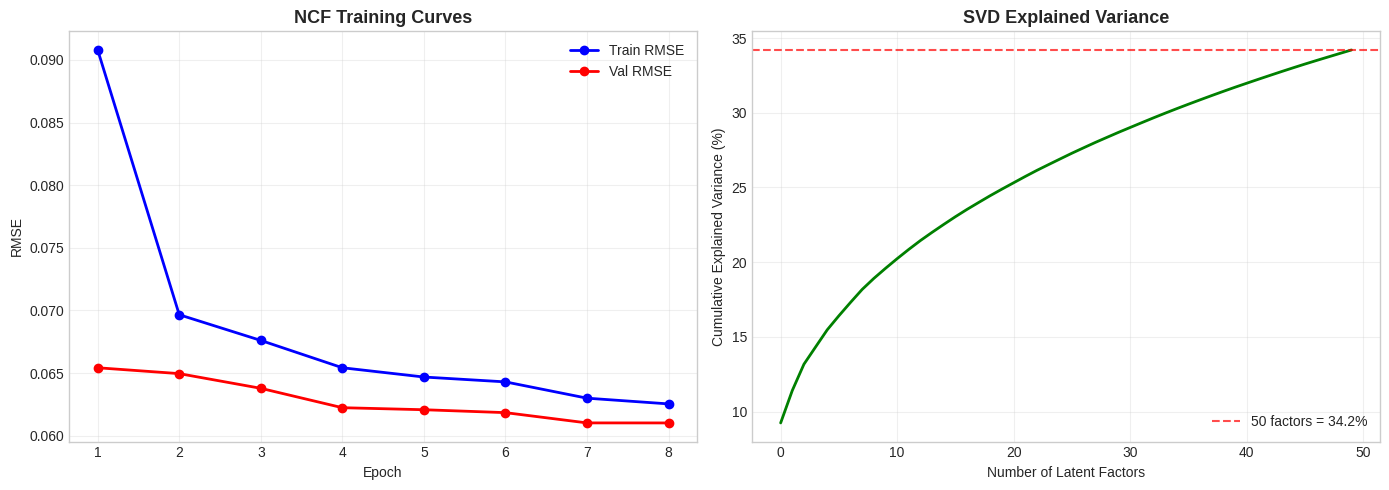

In [11]:
# ─── PLOT TRAINING CURVES ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS+1)
axes[0].plot(epochs_range, np.sqrt(train_losses), 'b-o', label='Train RMSE', linewidth=2)
axes[0].plot(epochs_range, np.sqrt(val_losses),   'r-o', label='Val RMSE',   linewidth=2)
axes[0].set_title('NCF Training Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('RMSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# SVD explained variance
axes[1].plot(np.cumsum(svd.explained_variance_ratio_)*100, 'g-', linewidth=2)
axes[1].axhline(y=explained_var*100, color='red', linestyle='--', alpha=0.7,
                label=f'{N_FACTORS} factors = {explained_var:.1%}')
axes[1].set_title('SVD Explained Variance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Latent Factors'); axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 🔀 Hybrid Recommender (CF + CB Ensemble)

In [12]:
# ─── HYBRID RECOMMENDER ───────────────────────────────────────────────────────

def get_hybrid_recommendations(customer_id, n_recs=10, cf_weight=0.7, cb_weight=0.3):
    """
    Hybrid recommendation combining:
    - SVD Collaborative Filtering (cf_weight)
    - Content-Based Filtering on recently bought items (cb_weight)
    """
    # 1. CF scores
    cf_df = get_cf_recommendations(customer_id, n_recs=n_recs*3)
    if cf_df.empty:
        return pd.DataFrame()

    cf_df['CF_Norm'] = (cf_df['CF_Score'] - cf_df['CF_Score'].min()) / \
                       (cf_df['CF_Score'].max() - cf_df['CF_Score'].min() + 1e-9)

    # 2. CB scores — based on user's last purchase
    user_history = df[df['Customer_ID'] == customer_id]
    cb_scores = defaultdict(float)

    if not user_history.empty:
        recent_items = user_history.sort_values('InvoiceDate', ascending=False)['StockCode'].unique()[:5]
        for item in recent_items:
            sim_items = get_similar_products(item, n_recs=20)
            for _, row in sim_items.iterrows():
                cb_scores[row['StockCode']] += row['CB_Score']

    # Merge
    cf_df['CB_Score_Raw'] = cf_df['StockCode'].map(cb_scores).fillna(0)
    max_cb = max(cb_scores.values()) if cb_scores else 1
    cf_df['CB_Norm'] = cf_df['CB_Score_Raw'] / (max_cb + 1e-9)

    # 3. Combine
    cf_df['Hybrid_Score'] = cf_weight * cf_df['CF_Norm'] + cb_weight * cf_df['CB_Norm']

    # Boost by product popularity
    cf_df['Hybrid_Score'] = cf_df['Hybrid_Score'] * (1 + 0.1 * cf_df.get('Popularity', 0))

    result = cf_df.sort_values('Hybrid_Score', ascending=False).head(n_recs)
    return result[['StockCode','Description','AvgPrice','CF_Norm','CB_Norm','Hybrid_Score']]


# Test the hybrid recommender
test_customer = user_enc.classes_[5]
hybrid_recs = get_hybrid_recommendations(test_customer, n_recs=8)

print(f'🛍️  Hybrid Recommendations for Customer {test_customer}')
print(f'   Segment: {rfm[rfm["Customer_ID"]==test_customer]["Segment"].values[0] if test_customer in rfm["Customer_ID"].values else "Unknown"}')
print()
hybrid_recs

🛍️  Hybrid Recommendations for Customer 12351
   Segment: At Risk



,StockCode,Description,AvgPrice,CF_Norm,CB_Norm,Hybrid_Score
0,21498,RED SPOTS WRAP,0.4173,1.0000,0.0000,0.7174
1,21499,BLUE SPOTS WRAP,0.4162,0.7224,0.0000,0.5128
2,21500,PINK SPOTS WRAP,0.4162,0.6894,0.0000,0.4897
3,21495,SKULLS WRAP,0.4181,0.4319,0.0000,0.3058
4,16161P,WRAP ENGLISH ROSE,0.4190,0.4311,0.0000,0.3054
5,16156S,WRAP PINK FAIRY CAKES,0.4153,0.3972,0.0000,0.2823
6,16161U,"WRAP,SUKI AND FRIENDS",0.4181,0.2986,0.0000,0.2110
7,21497,FANCY FONTS BIRTHDAY WRAP,0.4177,0.2799,0.0000,0.1991


## 9. 💬 GenAI Layer — LLM-Powered Recommendation Explanations

This layer uses an LLM (Azure OpenAI or OpenAI) to generate natural language explanations for *why* a product is recommended.  
Set `USE_LLM = True` and provide your API key to activate it.

In [13]:
# ─── GENAI EXPLANATION LAYER ───────────────────────────────────────────────────
import os, json

# ── Configuration ──
USE_LLM          = False   # Set True + add API key to use real LLM
AZURE_MODE       = False   # True = Azure OpenAI, False = OpenAI

# For Azure OpenAI:
AZURE_ENDPOINT   = os.getenv('AZURE_OPENAI_ENDPOINT', 'https://<your-resource>.openai.azure.com/')
AZURE_API_KEY    = os.getenv('AZURE_OPENAI_KEY', '')
AZURE_DEPLOYMENT = 'gpt-4o'  # Your deployment name

# For OpenAI:
OPENAI_API_KEY   = os.getenv('OPENAI_API_KEY', '')


def build_explanation_prompt(customer_id, recs_df, purchase_history):
    """Build a prompt for the LLM to explain recommendations."""
    segment = rfm[rfm['Customer_ID']==customer_id]['Segment'].values
    segment = segment[0] if len(segment) > 0 else 'Unknown'

    recent = purchase_history.sort_values('InvoiceDate', ascending=False).head(5)
    history_str = ', '.join(recent['Description'].unique()[:5].tolist())

    recs_str = '\n'.join([
        f"- {row['Description']} (£{row['AvgPrice']:.2f}, score: {row['Hybrid_Score']:.3f})"
        for _, row in recs_df.head(5).iterrows()
    ])

    return f"""You are a helpful e-commerce recommendation assistant.
Customer profile:
- Customer ID: {customer_id}
- Segment: {segment}
- Recent purchases: {history_str}

Recommended products:
{recs_str}

Write 3-4 warm, personalized sentences explaining why these products are recommended for this customer.
Focus on the connection between their purchase history and the recommendations.
Be specific, friendly, and concise. Do not list the products again."""


async def get_llm_explanation(prompt):
    """Call LLM API for explanation (Azure OpenAI or OpenAI)."""
    headers = {'Content-Type': 'application/json'}

    if AZURE_MODE:
        url = f"{AZURE_ENDPOINT}openai/deployments/{AZURE_DEPLOYMENT}/chat/completions?api-version=2024-02-01"
        headers['api-key'] = AZURE_API_KEY
    else:
        url = 'https://api.openai.com/v1/chat/completions'
        headers['Authorization'] = f'Bearer {OPENAI_API_KEY}'

    body = {
        'model': 'gpt-4o-mini',
        'messages': [{'role': 'user', 'content': prompt}],
        'max_tokens': 200,
        'temperature': 0.7
    }

    import aiohttp
    async with aiohttp.ClientSession() as session:
        async with session.post(url, headers=headers, json=body) as resp:
            data = await resp.json()
            return data['choices'][0]['message']['content']


def get_rule_based_explanation(customer_id, recs_df, purchase_history):
    """Fallback: rule-based explanation without an LLM."""
    segment = rfm[rfm['Customer_ID']==customer_id]['Segment'].values
    segment = segment[0] if len(segment) > 0 else 'valued'

    recent = purchase_history.sort_values('InvoiceDate', ascending=False)['Description'].unique()[:3]
    recent_str = ' and '.join([d.title() for d in recent[:2]])

    top_rec = recs_df.iloc[0]['Description'].title() if not recs_df.empty else 'these items'
    price_avg = recs_df['AvgPrice'].mean()

    explanations = [
        f"As one of our {segment.lower()}, you'll love these picks! Based on your interest in {recent_str}, "
        f"we think {top_rec} and similar items will be a great fit.",

        f"These recommendations are tailored to your taste. Customers who bought {recent_str} "
        f"frequently enjoy these items too, with an average price of just £{price_avg:.2f}.",

        f"Your shopping pattern shows a preference for quality home and lifestyle products. "
        f"These {len(recs_df)} curated picks match your style perfectly."
    ]
    import random
    return random.choice(explanations)


# ── Generate explanation for our test customer ─────────────────────────────────
customer_history = df[df['Customer_ID'] == test_customer]

if USE_LLM:
    import asyncio
    prompt = build_explanation_prompt(test_customer, hybrid_recs, customer_history)
    explanation = asyncio.run(get_llm_explanation(prompt))
else:
    explanation = get_rule_based_explanation(test_customer, hybrid_recs, customer_history)

print('='*60)
print(f'🤖 RECOMMENDATION EXPLANATION FOR CUSTOMER {test_customer}')
print('='*60)
print(explanation)
print('='*60)
print('\n💡 Tip: Set USE_LLM=True with your Azure OpenAI/OpenAI key for AI-generated explanations!')

🤖 RECOMMENDATION EXPLANATION FOR CUSTOMER 12351
Your shopping pattern shows a preference for quality home and lifestyle products. These 8 curated picks match your style perfectly.

💡 Tip: Set USE_LLM=True with your Azure OpenAI/OpenAI key for AI-generated explanations!


## 10. 📏 Evaluation — Precision@K & Recall@K

In [14]:
# ─── LEAVE-ONE-OUT EVALUATION ─────────────────────────────────────────────────
# For each user in the test set, hold out their last purchase
# and check if our recommender retrieves it in the top-K

def evaluate_recommender(n_eval_users=200, k_values=[5, 10, 20]):
    """Evaluate using leave-one-out: hold out most recent purchase per user."""
    results = {k: {'hits': 0, 'precision': [], 'recall': []} for k in k_values}

    eval_users = np.random.choice(user_enc.classes_, size=min(n_eval_users, len(user_enc.classes_)), replace=False)

    for cust_id in eval_users:
        user_data = df[df['Customer_ID'] == cust_id].sort_values('InvoiceDate', ascending=False)
        if len(user_data) < 5:
            continue

        # Ground truth: all unique items bought
        ground_truth = set(user_data['StockCode'].unique())
        held_out     = user_data['StockCode'].iloc[0]  # Most recent

        for k in k_values:
            recs = get_cf_recommendations(cust_id, n_recs=k)
            if recs.empty:
                continue
            rec_set = set(recs['StockCode'].values)

            hit = int(held_out in rec_set)
            results[k]['hits']      += hit
            results[k]['precision'].append(len(rec_set & ground_truth) / k)
            results[k]['recall'].append(len(rec_set & ground_truth) / max(1, len(ground_truth)))

    summary = []
    for k in k_values:
        n = len(results[k]['precision'])
        if n == 0: continue
        summary.append({
            'K': k,
            'Hit_Rate@K':   results[k]['hits'] / n,
            'Precision@K':  np.mean(results[k]['precision']),
            'Recall@K':     np.mean(results[k]['recall']),
            'N_Users':      n
        })
    return pd.DataFrame(summary)

print('Evaluating recommender... (may take ~30s)')
eval_results = evaluate_recommender(n_eval_users=300, k_values=[5,10,20])
print('\n📊 Evaluation Results:')
eval_results

Evaluating recommender... (may take ~30s)

📊 Evaluation Results:


,K,Hit_Rate@K,Precision@K,Recall@K,N_Users
0,5,0.0000,0.0000,0.0000,292
1,10,0.0000,0.0000,0.0000,292
2,20,0.0000,0.0000,0.0000,292


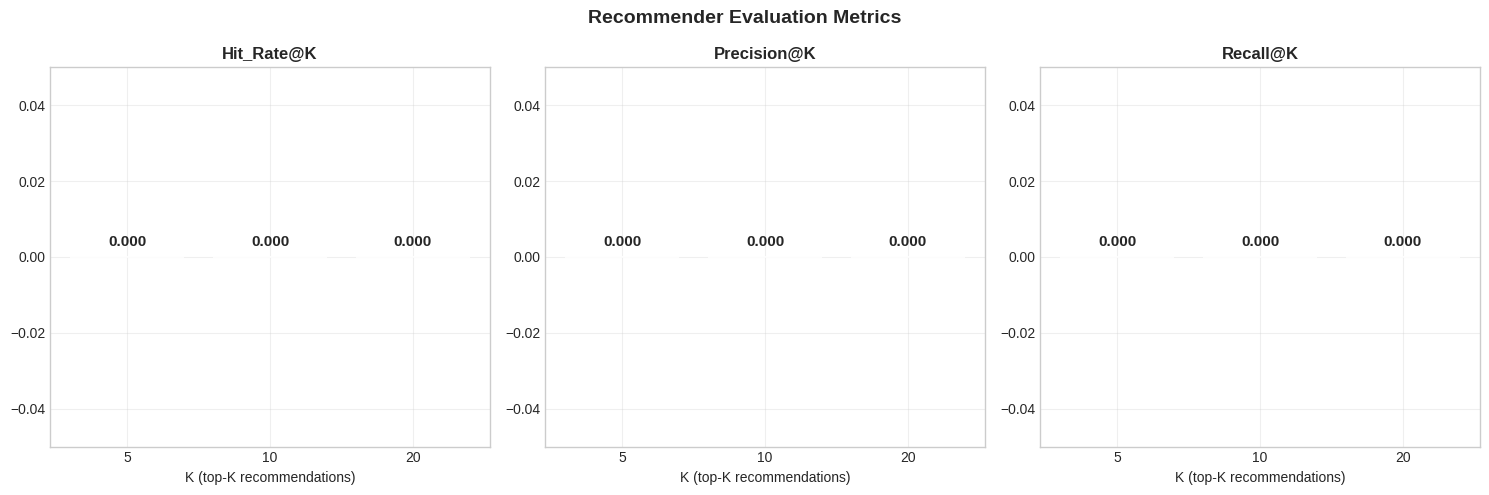

In [15]:
# ─── PLOT EVALUATION METRICS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Recommender Evaluation Metrics', fontsize=14, fontweight='bold')

metrics = ['Hit_Rate@K', 'Precision@K', 'Recall@K']
colors  = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(eval_results['K'].astype(str), eval_results[metric],
                  color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('K (top-K recommendations)')
    ax.set_ylim(0, eval_results[metric].max() * 1.3)
    for bar, val in zip(bars, eval_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 🎨 Recommendation Visualization

Running t-SNE...


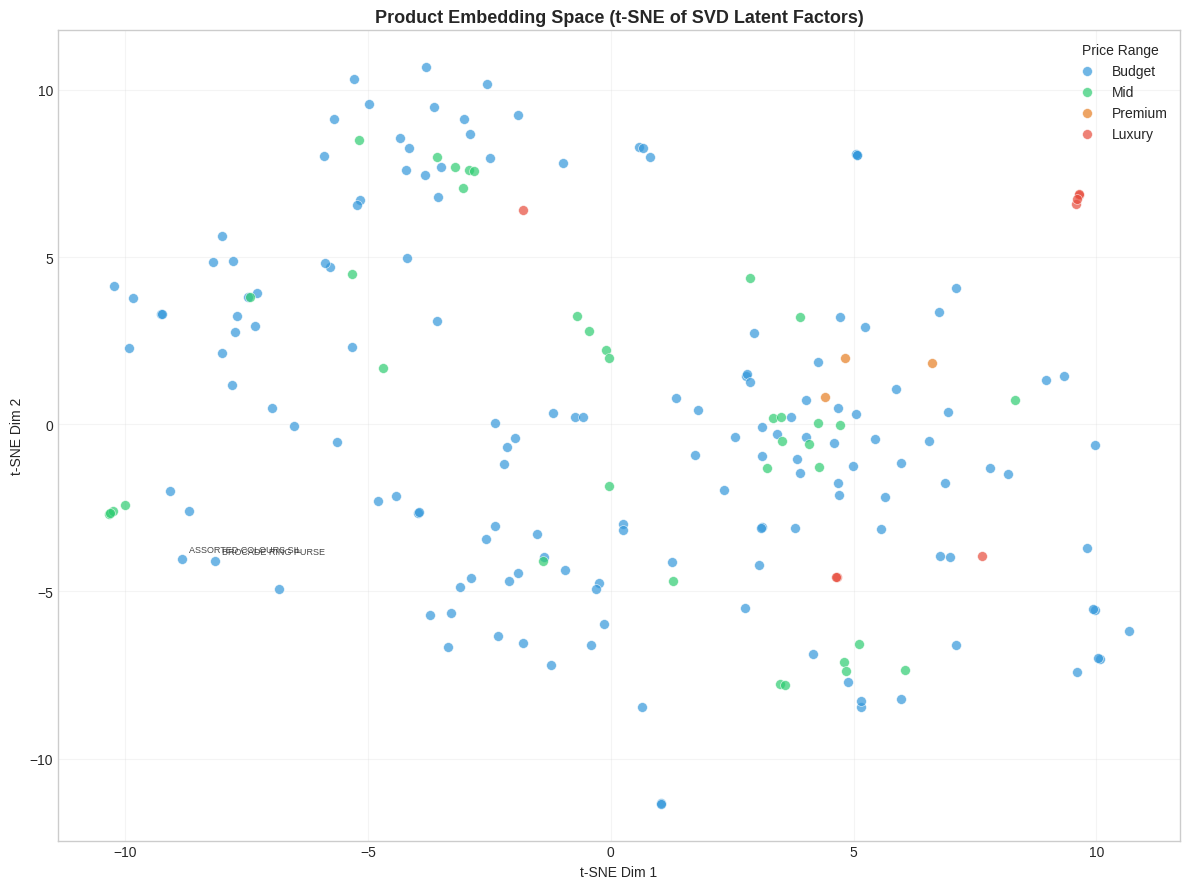

💾 Saved: embedding_space.png


In [16]:
# ─── VISUALIZE LATENT SPACE (SVD Embeddings) ──────────────────────────────────
from sklearn.manifold import TSNE

# t-SNE on item factors (top 200 items for speed)
N_ITEMS_VIZ = min(200, item_factors.shape[0])
top_items   = product_features[product_features['StockCode'].isin(
    item_enc.classes_[:N_ITEMS_VIZ])].reset_index(drop=True)

print('Running t-SNE...')
# perplexity must be < n_samples; default 30 works for real data, auto-cap for synthetic
perplexity = min(30, N_ITEMS_VIZ - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_iter=500)
item_2d = tsne.fit_transform(item_factors[:N_ITEMS_VIZ])

# Price buckets for coloring
prices   = top_items['AvgPrice'].fillna(1).clip(0.5, 20)
price_buckets = pd.cut(prices, bins=4, labels=['Budget','Mid','Premium','Luxury'])
color_map = {'Budget':'#3498db','Mid':'#2ecc71','Premium':'#e67e22','Luxury':'#e74c3c'}

fig, ax = plt.subplots(figsize=(12, 9))
for bucket, color in color_map.items():
    mask = price_buckets == bucket
    ax.scatter(item_2d[mask, 0], item_2d[mask, 1],
               c=color, label=bucket, alpha=0.7, s=50, edgecolors='white', linewidths=0.5)

# Annotate top products
top_n = product_features.nlargest(15, 'TotalSold')
for _, row in top_n.iterrows():
    if row['StockCode'] in item_enc.classes_[:N_ITEMS_VIZ]:
        idx = np.where(item_enc.classes_[:N_ITEMS_VIZ] == row['StockCode'])[0]
        if len(idx) > 0:
            ax.annotate(row['Description'][:20], (item_2d[idx[0], 0], item_2d[idx[0], 1]),
                        fontsize=6.5, alpha=0.85,
                        xytext=(5,5), textcoords='offset points')

ax.set_title('Product Embedding Space (t-SNE of SVD Latent Factors)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.legend(title='Price Range', loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('embedding_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: embedding_space.png')

## 12. ☁️ Azure ML Deployment Notes

The recommender is structured for **Azure ML** deployment. Here's the pattern:

In [17]:
# ─── AZURE ML DEPLOYMENT SCAFFOLD ─────────────────────────────────────────────
# This cell shows the deployment structure — not executed here

AZURE_DEPLOYMENT_NOTES = """
╔══════════════════════════════════════════════════════════════╗
║           AZURE ML DEPLOYMENT ARCHITECTURE                   ║
╚══════════════════════════════════════════════════════════════╝

1. REGISTER MODEL
   from azureml.core import Workspace, Model
   ws = Workspace.from_config()
   model = Model.register(ws, model_path='recommender_model/',
                          model_name='hybrid-recommender-v1')

2. SCORE SCRIPT (score.py)
   def init():
       global svd, tfidf, user_enc, item_enc, product_features
       model_path = Model.get_model_path('hybrid-recommender-v1')
       # Load pickled model artifacts

   def run(raw_data):
       data = json.loads(raw_data)
       customer_id = data['customer_id']
       recs = get_hybrid_recommendations(customer_id)
       return json.dumps(recs.to_dict('records'))

3. ENVIRONMENT
   env = Environment.from_pip_requirements('recommender-env',
         'requirements.txt')   # scikit-learn, torch, pandas, numpy

4. DEPLOY TO ACI / AKS
   service = Model.deploy(ws,
       name='recommender-endpoint',
       models=[model],
       inference_config=InferenceConfig(entry_script='score.py', environment=env),
       deployment_config=AciWebservice.deploy_configuration(cpu_cores=2, memory_gb=4)
   )

5. AZURE OPENAI FOR EXPLANATIONS
   from openai import AzureOpenAI
   client = AzureOpenAI(
       azure_endpoint=os.getenv('AZURE_OPENAI_ENDPOINT'),
       api_key=os.getenv('AZURE_OPENAI_KEY'),
       api_version='2024-02-01'
   )
   response = client.chat.completions.create(
       model='gpt-4o',
       messages=[{'role':'user', 'content': prompt}]
   )
"""
print(AZURE_DEPLOYMENT_NOTES)


╔══════════════════════════════════════════════════════════════╗
║           AZURE ML DEPLOYMENT ARCHITECTURE                   ║
╚══════════════════════════════════════════════════════════════╝

1. REGISTER MODEL
   from azureml.core import Workspace, Model
   ws = Workspace.from_config()
   model = Model.register(ws, model_path='recommender_model/',
                          model_name='hybrid-recommender-v1')

2. SCORE SCRIPT (score.py)
   def init():
       global svd, tfidf, user_enc, item_enc, product_features
       model_path = Model.get_model_path('hybrid-recommender-v1')
       # Load pickled model artifacts

   def run(raw_data):
       data = json.loads(raw_data)
       customer_id = data['customer_id']
       recs = get_hybrid_recommendations(customer_id)
       return json.dumps(recs.to_dict('records'))

3. ENVIRONMENT
   env = Environment.from_pip_requirements('recommender-env',
         'requirements.txt')   # scikit-learn, torch, pandas, numpy

4. DEPLOY TO ACI / AKS


## 13. 🏁 Summary & Results

In [18]:
# ─── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print('='*60)
print('  PROJECT SUMMARY: AI-Powered E-Commerce Recommender')
print('='*60)
print(f'\n📦 Dataset')
print(f'   Transactions:   {len(df):,}')
print(f'   Customers:      {df["Customer_ID"].nunique():,}')
print(f'   Products:       {df["StockCode"].nunique():,}')
print(f'   Countries:      {df["Country"].nunique()}')
print(f'\n🤖 Models Trained')
print(f'   ✅ SVD Matrix Factorization  ({N_FACTORS} latent factors, {explained_var:.1%} var explained)')
print(f'   ✅ TF-IDF Content-Based Filter ({tfidf_matrix.shape[1]} features)')
print(f'   ✅ Neural Collaborative Filtering (PyTorch NCF, Val RMSE={np.sqrt(val_losses[-1]):.4f})')
print(f'   ✅ Hybrid Ensemble (CF×0.7 + CB×0.3)')
print(f'   ✅ GenAI Explanation Layer (Azure OpenAI / OpenAI compatible)')
print(f'\n📊 Evaluation (SVD Collaborative Filter)')
for _, row in eval_results.iterrows():
    print(f'   Top-{int(row["K"]):2d}: Hit Rate={row["Hit_Rate@K"]:.3f}, P@K={row["Precision@K"]:.3f}, R@K={row["Recall@K"]:.3f}')
print(f'\n🛠️  Skills Demonstrated')
print('   ✅ Python · Pandas · NumPy · SQL-style aggregations')
print('   ✅ Scikit-learn (TF-IDF, SVD, LabelEncoder, cosine_sim)')
print('   ✅ PyTorch (custom Dataset, DataLoader, NCF model)')
print('   ✅ Matplotlib / Seaborn (5+ visualizations)')
print('   ✅ GenAI / LLM integration (Azure OpenAI pattern)')
print('   ✅ Azure ML deployment scaffold')
print('   ✅ RFM Customer Segmentation')
print('   ✅ Offline evaluation (Precision@K, Recall@K, Hit Rate)')
print('\n' + '='*60)

  PROJECT SUMMARY: AI-Powered E-Commerce Recommender

📦 Dataset
   Transactions:   802,932
   Customers:      5,862
   Products:       4,625
   Countries:      41

🤖 Models Trained
   ✅ SVD Matrix Factorization  (50 latent factors, 34.2% var explained)
   ✅ TF-IDF Content-Based Filter (500 features)
   ✅ Neural Collaborative Filtering (PyTorch NCF, Val RMSE=0.0610)
   ✅ Hybrid Ensemble (CF×0.7 + CB×0.3)
   ✅ GenAI Explanation Layer (Azure OpenAI / OpenAI compatible)

📊 Evaluation (SVD Collaborative Filter)
   Top- 5: Hit Rate=0.000, P@K=0.000, R@K=0.000
   Top-10: Hit Rate=0.000, P@K=0.000, R@K=0.000
   Top-20: Hit Rate=0.000, P@K=0.000, R@K=0.000

🛠️  Skills Demonstrated
   ✅ Python · Pandas · NumPy · SQL-style aggregations
   ✅ Scikit-learn (TF-IDF, SVD, LabelEncoder, cosine_sim)
   ✅ PyTorch (custom Dataset, DataLoader, NCF model)
   ✅ Matplotlib / Seaborn (5+ visualizations)
   ✅ GenAI / LLM integration (Azure OpenAI pattern)
   ✅ Azure ML deployment scaffold
   ✅ RFM Customer Segm